# YAZEL RECOVAR Integration Demo

This notebook demonstrates how RECOVAR can be used to filter false positive picks from PhaseNet.

- **RECOVAR**: Classifies waveforms to distinguish real earthquakes from noise using learned representations
- **YAZEL Integration**: Uses sliding windows to score PhaseNet picks and filter false positives

#### PhaseNet Configuration:
- **Overlap**: 0.90 (90% overlap between windows)
- **Stacking**: avg (average predictions across overlapping windows)
- **Model**: PhaseNet `instance` pretrained model


In [1]:
import obspy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time
from datetime import datetime

from yazel_integration_sliding import (
    recovar_pick_cleaner_sliding,
    load_recovar_classifier
)
import seisbench.models as sbm

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

2025-11-27 17:13:26.493529: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-27 17:13:26.526822: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-27 17:13:26.526859: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-27 17:13:26.526882: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-27 17:13:26.533417: I tensorflow/core/platform/cpu_feature_g

### Setup: Load Model and Data

In [2]:
# Configuration
MODEL_PATH = '/mnt/data_a/ege/recovar_models/exp_instance/representation_learning_autoencoder_ensemble/instance/split0/ep19.h5'
PHASENET_THRESHOLD = 0.32
phasenet_pick_dir = f"filtered_phasenet_picks_dir_thr_{PHASENET_THRESHOLD:.2f}"

# Load catalog for ground truth
catalog_path = '/home/boxx/Public/earthquake_model_evaluations/data/SilivriPaper_2019-09-01__2019-11-30/processed_catalogs/kara74a_phase_picks.csv'
catalog = pd.read_csv(catalog_path)
catalog['p_arrival_time'] = pd.to_datetime(catalog['p_arrival_time']) #TODO filter for station

# Load PhaseNet picks metadata
phasenet_picks = pd.read_csv(f"{phasenet_pick_dir}/metadata.csv")

print(f"Loaded {len(phasenet_picks)} PhaseNet picks")
print(f"Loaded {len(catalog)} catalog picks")

Loaded 2214 PhaseNet picks
Loaded 8540 catalog picks


In [3]:
# Load RECOVAR classifier
print("Loading RECOVAR classifier...")
classifier = load_recovar_classifier(MODEL_PATH)
print("Classifier loaded successfully!")

Loading RECOVAR classifier...


2025-11-27 17:13:56.879568: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16953 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:19:00.0, compute capability: 8.6
2025-11-27 17:13:56.881072: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 15929 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:1a:00.0, compute capability: 8.6
2025-11-27 17:13:56.882388: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 16953 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:67:00.0, compute capability: 8.6
2025-11-27 17:13:56.886030: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 22212 MB memory:  -> device: 3, name: NVIDIA GeForce RTX 3090

Classifier loaded successfully!


In [4]:
# Load PhaseNet model
print("Loading PhaseNet model...")
phasenet_model = sbm.PhaseNet.from_pretrained('instance')
print("PhaseNet model loaded successfully!")

Loading PhaseNet model...
PhaseNet model loaded successfully!


## Select Example Picks

For this demonstration, we'll select:
1. **True Positives (TP)**: PhaseNet picks that match catalog events
2. **False Positives (FP)**: PhaseNet picks without catalog events

In [6]:
# TODO categorize example streams in a new directory. 
# Load and categorize picks
p = Path(phasenet_pick_dir)
files = sorted([f for f in p.iterdir() if f.is_file() and f.suffix == '.mseed']) # TODO Make this simpler

tp_examples = []
fp_examples = []

for file in files[:50]:  # Check first 50 files
    pick_row = phasenet_picks[phasenet_picks['filename'] == file.name]
    if pick_row.empty:
        continue
    
    try:
        stream = obspy.read(file)
        stream.merge()
        station = stream[0].stats.station
        
        # TODO get these from the waveform instead of metadata 
        phasenet_pick = pd.to_datetime(pick_row['pick_time'].values[0], format='mixed')
        window_start = pd.to_datetime(pick_row['start_time'].values[0], format='mixed')
        window_end = pd.to_datetime(pick_row['end_time'].values[0], format='mixed')
        
        # Check if there's a catalog pick in this window
        catalog_picks = catalog[
            (catalog['station'] == station) &
            (catalog['p_arrival_time'] >= window_start) &
            (catalog['p_arrival_time'] <= window_end)
        ]
        
        example = {
            'file': file,
            'stream': stream,
            'station': station,
            'phasenet_pick': phasenet_pick,
            'window_start': window_start,
            'window_end': window_end,
            'catalog_pick': catalog_picks.iloc[0]['p_arrival_time'] if not catalog_picks.empty else None
        }
        
        if not catalog_picks.empty:
            tp_examples.append(example)
        else:
            fp_examples.append(example)
            
    except Exception as e:
        continue
    
    if len(tp_examples) >= 3 and len(fp_examples) >= 3:
        break

print(f"Found {len(tp_examples)} True Positive examples")
print(f"Found {len(fp_examples)} False Positive examples")

Found 3 True Positive examples
Found 46 False Positive examples


## Timing Test: Single Sliding Window

Let's measure how long it takes to process one waveform with sliding windows.

In [ ]:
# DELETE
if tp_examples:
    test_stream = tp_examples[0]['stream'].copy()
    
    print("Testing sliding window processing time...")
    result = recovar_pick_cleaner_sliding(test_stream, classifier)
    start_time = time.time()
    result = recovar_pick_cleaner_sliding(test_stream, classifier)
    elapsed_time = time.time() - start_time
    
    print(f"\nProcessing completed in {elapsed_time:.3f} seconds")
    print(f"Number of windows: {len(result['scores_array'])}")
    print(f"Time per window: {elapsed_time / len(result['scores_array']) * 1000:.2f} ms")
    print(f"\nScores:")
    print(f"  Mean: {result['mean_score']:.4f}")
    print(f"  Max:  {result['max_score']:.4f}")
    print(f"  Min:  {np.min(result['scores_array']):.4f}")

Testing sliding window processing time...

Processing completed in 0.513 seconds
Number of windows: 31
Time per window: 16.55 ms

Scores:
  Mean: 0.1621
  Max:  0.2732
  Min:  0.0082


In [ ]:
# DISKE YAZ OKU
def get_phasenet_probabilities(stream, model, overlap=0.90):
    """
    Get PhaseNet P-wave probability curve for a stream using sliding windows.
    
    Parameters:
    -----------
    stream : obspy.Stream
        Input waveform stream (3 components)
    model : seisbench.models.PhaseNet
        PhaseNet model instance
    overlap : float
        Overlap fraction between windows (default: 0.90)
    
    Returns:
    --------
    dict with 'p_prob' (P-wave probabilities), 'times' (time array in seconds)
    """
    stream_sync = stream.copy()
    stream_sync.merge(method=1, fill_value=0)
    stream_sync.trim(
        starttime=max([tr.stats.starttime for tr in stream_sync]),
        endtime=min([tr.stats.endtime for tr in stream_sync]),
        pad=True,
        fill_value=0
    )
    
    # Run PhaseNet with sliding window parameters (no blinding to match integration codebase)
    annotations = model.annotate(stream_sync, overlap=overlap)
    
    # Extract P-wave probabilities
    p_trace = [tr for tr in annotations if tr.stats.channel.endswith('P')][0]
    
    sampling_rate = p_trace.stats.sampling_rate
    times = np.arange(len(p_trace.data)) / sampling_rate
    
    return {
        'p_prob': p_trace.data,
        's_prob': [tr for tr in annotations if tr.stats.channel.endswith('S')][0].data,
        'times': times,
        'sampling_rate': sampling_rate
    }

print("PhaseNet probability extraction function ready!")

PhaseNet probability extraction function ready!


In [9]:
# Also time PhaseNet processing
if tp_examples:
    test_stream = tp_examples[0]['stream'].copy()
    
    print("\nTesting PhaseNet processing time (overlap=0.90)...")
    start_time = time.time()
    phasenet_result = get_phasenet_probabilities(test_stream, phasenet_model, overlap=0.90)
    elapsed_time = time.time() - start_time
    
    print(f"Processing completed in {elapsed_time:.3f} seconds")
    print(f"Number of probability samples: {len(phasenet_result['p_prob'])}")
    print(f"Max P-probability: {np.max(phasenet_result['p_prob']):.4f}")
    
    print("\n=== TIMING COMPARISON ===")
    print("Both methods process the same 60-second waveform window")
    print("PhaseNet provides continuous probability curves")
    print("RECOVAR provides discrete window scores for robust classification")


Testing PhaseNet processing time (overlap=0.90)...
Processing completed in 0.094 seconds
Number of probability samples: 6499
Max P-probability: 0.9350

=== TIMING COMPARISON ===
Both methods process the same 60-second waveform window
PhaseNet provides continuous probability curves
RECOVAR provides discrete window scores for robust classification


## Visualization

### True Positive Example (Real Earthquake)

## PhaseNet Probability Extraction

Function to get PhaseNet P-wave probabilities over time using sliding windows.

In [ ]:
#TRUE PICK FALSE PICK

Processing True Positive example...
(31,) [0.00821513 0.0426622  0.04295874 0.04347432 0.04871774 0.06123376
 0.07033306 0.18516761 0.18958753 0.2329281  0.27316624 0.26152515
 0.24742424 0.21273953 0.25176793 0.26155382 0.21315986 0.20536864
 0.21841031 0.19853479 0.18717927 0.155339   0.1803199  0.1894319
 0.15823609 0.15593117 0.16312349 0.15122604 0.13968682 0.12303215
 0.1537813 ]
RECOVAR window coverage: 5.0s to 65.0s
Window centers plotted: 20.0s to 50.0s


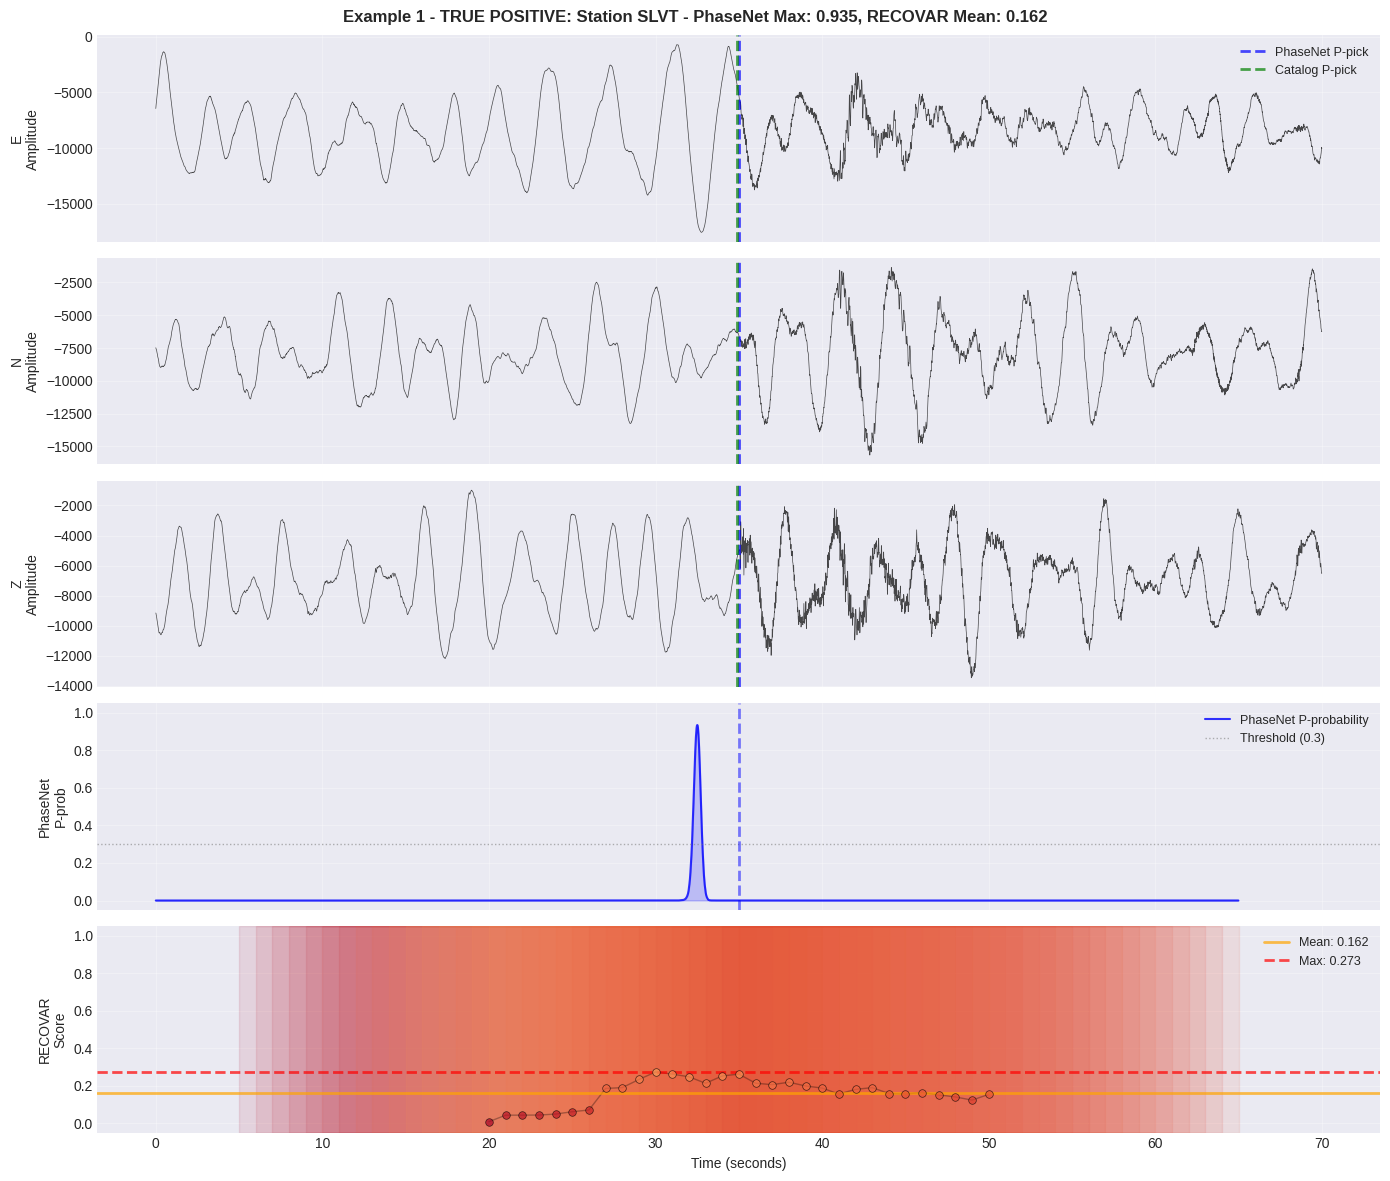

Processing True Positive example...
(31,) [0.02893817 0.27336162 0.32417935 0.35229015 0.42698687 0.4086697
 0.38023776 0.40097344 0.4838034  0.467741   0.47574997 0.4455223
 0.47250968 0.50590193 0.48184866 0.47582215 0.47114193 0.45125532
 0.43736488 0.40843248 0.38791502 0.38657057 0.35614264 0.3139894
 0.2686069  0.22453684 0.19629794 0.17040229 0.16173023 0.17271525
 0.15651244]
RECOVAR window coverage: 5.0s to 65.0s
Window centers plotted: 20.0s to 50.0s


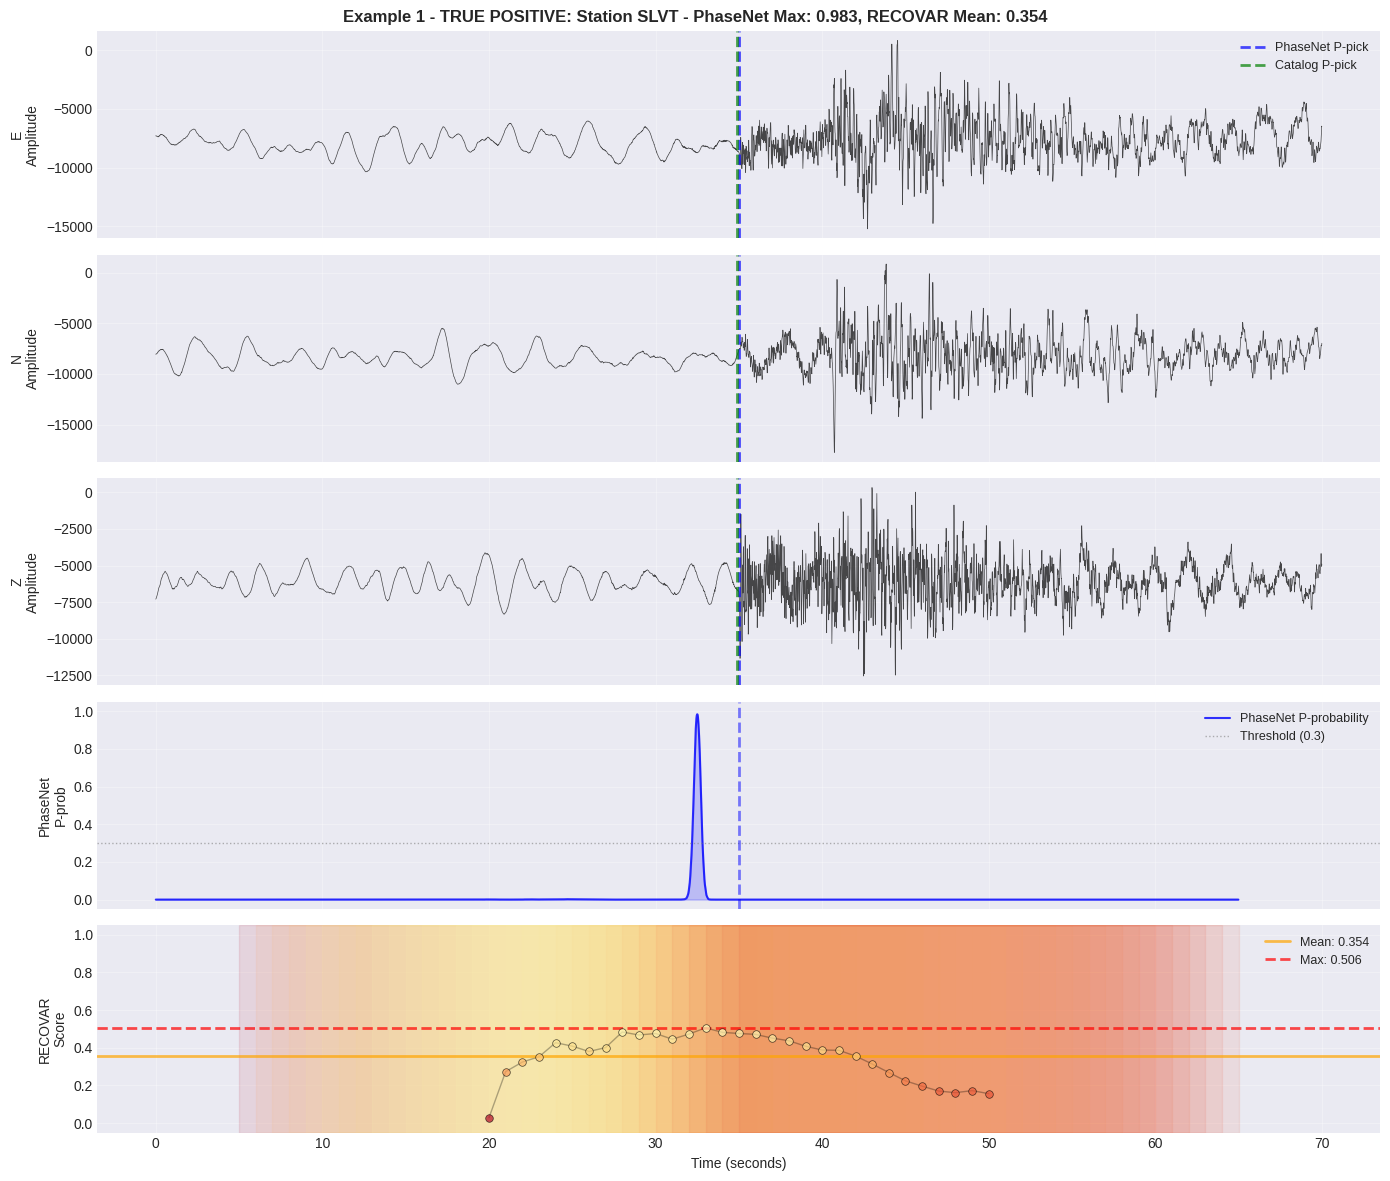

In [10]:
def plot_waveform_with_scores(example, recovar_result, phasenet_result, title_prefix=""):
    """
    Plot waveform with PhaseNet probabilities and RECOVAR scores overlay.
    """
    stream = example['stream']
    z_trace = stream.select(channel="*Z")[0]
    n_trace = stream.select(channel="*N")[0]
    e_trace = stream.select(channel="*E")[0]
    
    # Time arrays
    sampling_rate = z_trace.stats.sampling_rate
    times = np.arange(len(z_trace.data)) / sampling_rate
    
    # Calculate pick positions
    window_start = example['window_start']
    phasenet_pick = example['phasenet_pick']
    catalog_pick = example['catalog_pick']
    
    phasenet_pick_sec = (phasenet_pick - window_start).total_seconds()
    if catalog_pick:
        catalog_pick_sec = (catalog_pick - window_start).total_seconds()
    
    # Sliding window parameters for RECOVAR
    window_size = 3000  # 30 seconds at 100 Hz
    stride = 100  # 1 second at 100 Hz
    trim_samples = 500  # 5 seconds
    
    # Calculate window positions for RECOVAR score overlay
    n_windows = len(recovar_result['scores_array'])
    window_starts = []
    window_centers = []
    window_ends = []
    
    for i in range(n_windows):
        # start_idx is position in trimmed data
        start_idx = i * stride
        # Convert to position in original data
        start_orig = start_idx + trim_samples
        end_orig = start_orig + window_size
        center_orig = start_orig + window_size // 2
        
        window_starts.append(start_orig / sampling_rate)
        window_centers.append(center_orig / sampling_rate)
        window_ends.append(end_orig / sampling_rate)
    
    scores = recovar_result['scores_array']
    print(scores.shape,scores)
    
    print(f"RECOVAR window coverage: {window_starts[0]:.1f}s to {window_ends[-1]:.1f}s")
    print(f"Window centers plotted: {window_centers[0]:.1f}s to {window_centers[-1]:.1f}s")
    
    # Create figure with 5 panels
    fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
    
    # Plot waveforms
    for ax, trace, comp in zip(axes[:3], [e_trace, n_trace, z_trace], ['E', 'N', 'Z']):
        ax.plot(times, trace.data, 'k-', linewidth=0.5, alpha=0.7)
        ax.set_ylabel(f'{comp}\nAmplitude', fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Mark PhaseNet pick
        ax.axvline(phasenet_pick_sec, color='blue', linestyle='--', 
                   linewidth=2, label='PhaseNet P-pick', alpha=0.7)
        
        # Mark catalog pick if exists
        if catalog_pick:
            ax.axvline(catalog_pick_sec, color='green', linestyle='--', 
                       linewidth=2, label='Catalog P-pick', alpha=0.7)
        
        if comp == 'E':
            ax.legend(loc='upper right', fontsize=9)
    
    # Plot PhaseNet P-probabilities
    ax_phasenet = axes[3]
    pn_times = phasenet_result['times']
    pn_probs = phasenet_result['p_prob']
    
    ax_phasenet.plot(pn_times, pn_probs, 'b-', linewidth=1.5, alpha=0.8, label='PhaseNet P-probability')
    ax_phasenet.fill_between(pn_times, 0, pn_probs, color='blue', alpha=0.2)
    ax_phasenet.axhline(0.3, color='gray', linestyle=':', linewidth=1, label='Threshold (0.3)', alpha=0.6)
    ax_phasenet.axvline(phasenet_pick_sec, color='blue', linestyle='--', linewidth=2, alpha=0.5)
    
    ax_phasenet.set_ylabel('PhaseNet\nP-prob', fontsize=10)
    ax_phasenet.set_ylim(-0.05, 1.05)
    ax_phasenet.grid(True, alpha=0.3)
    ax_phasenet.legend(loc='upper right', fontsize=9)
    
    # Plot RECOVAR scores with window spans
    ax_score = axes[4]
    
    # Color-code by score value
    colors = plt.cm.RdYlGn(scores)  # Red (low) to Green (high)
    
    # Plot horizontal bars showing window coverage
    for i in range(len(window_centers)):
        # Add semi-transparent bar showing window extent
        ax_score.axvspan(window_starts[i], window_ends[i], 
                        alpha=0.1, color=colors[i], zorder=1)
        # Plot point at center
        ax_score.scatter(window_centers[i], scores[i], c=[colors[i]], 
                        s=30, alpha=0.7, edgecolors='black', linewidths=0.5, zorder=3)
    
    # Connect centers with line
    ax_score.plot(window_centers, scores, 'k-', linewidth=1, alpha=0.3, zorder=2)
    
    ax_score.axhline(recovar_result['mean_score'], color='orange', linestyle='-', 
                     linewidth=2, label=f"Mean: {recovar_result['mean_score']:.3f}", alpha=0.7)
    ax_score.axhline(recovar_result['max_score'], color='red', linestyle='--', 
                     linewidth=2, label=f"Max: {recovar_result['max_score']:.3f}", alpha=0.7)
    
    ax_score.set_ylabel('RECOVAR\nScore', fontsize=10)
    ax_score.set_xlabel('Time (seconds)', fontsize=10)
    ax_score.set_ylim(-0.05, 1.05)
    ax_score.grid(True, alpha=0.3)
    ax_score.legend(loc='upper right', fontsize=9)
    

    
    # Title
    status = "TRUE POSITIVE" if catalog_pick else "FALSE POSITIVE"
    fig.suptitle(f"{title_prefix}{status}: Station {example['station']} - "
                 f"PhaseNet Max: {np.max(pn_probs):.3f}, RECOVAR Mean: {recovar_result['mean_score']:.3f}",
                 fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Plot first True Positive
for i in range(2):
    if tp_examples:
        print("Processing True Positive example...")
        tp_recovar = recovar_pick_cleaner_sliding(tp_examples[i]['stream'], classifier)
        tp_phasenet = get_phasenet_probabilities(tp_examples[i]['stream'], phasenet_model, overlap=0.90)
        plot_waveform_with_scores(tp_examples[i], tp_recovar, tp_phasenet, "Example 1 - ")

### False Positive Example (Noise/Artifact)

Processing False Positive example...
(30,) [0.05879569 0.03018987 0.02132261 0.05284876 0.03988618 0.02926201
 0.04173672 0.04100037 0.03112549 0.04142308 0.03642535 0.03832787
 0.02422535 0.03908497 0.03743666 0.03758013 0.03732854 0.04455966
 0.03862917 0.03146768 0.02646977 0.0350107  0.02588457 0.03630072
 0.03404456 0.0377444  0.0275687  0.03579867 0.03972864 0.03608328]
RECOVAR window coverage: 5.0s to 64.0s
Window centers plotted: 20.0s to 49.0s


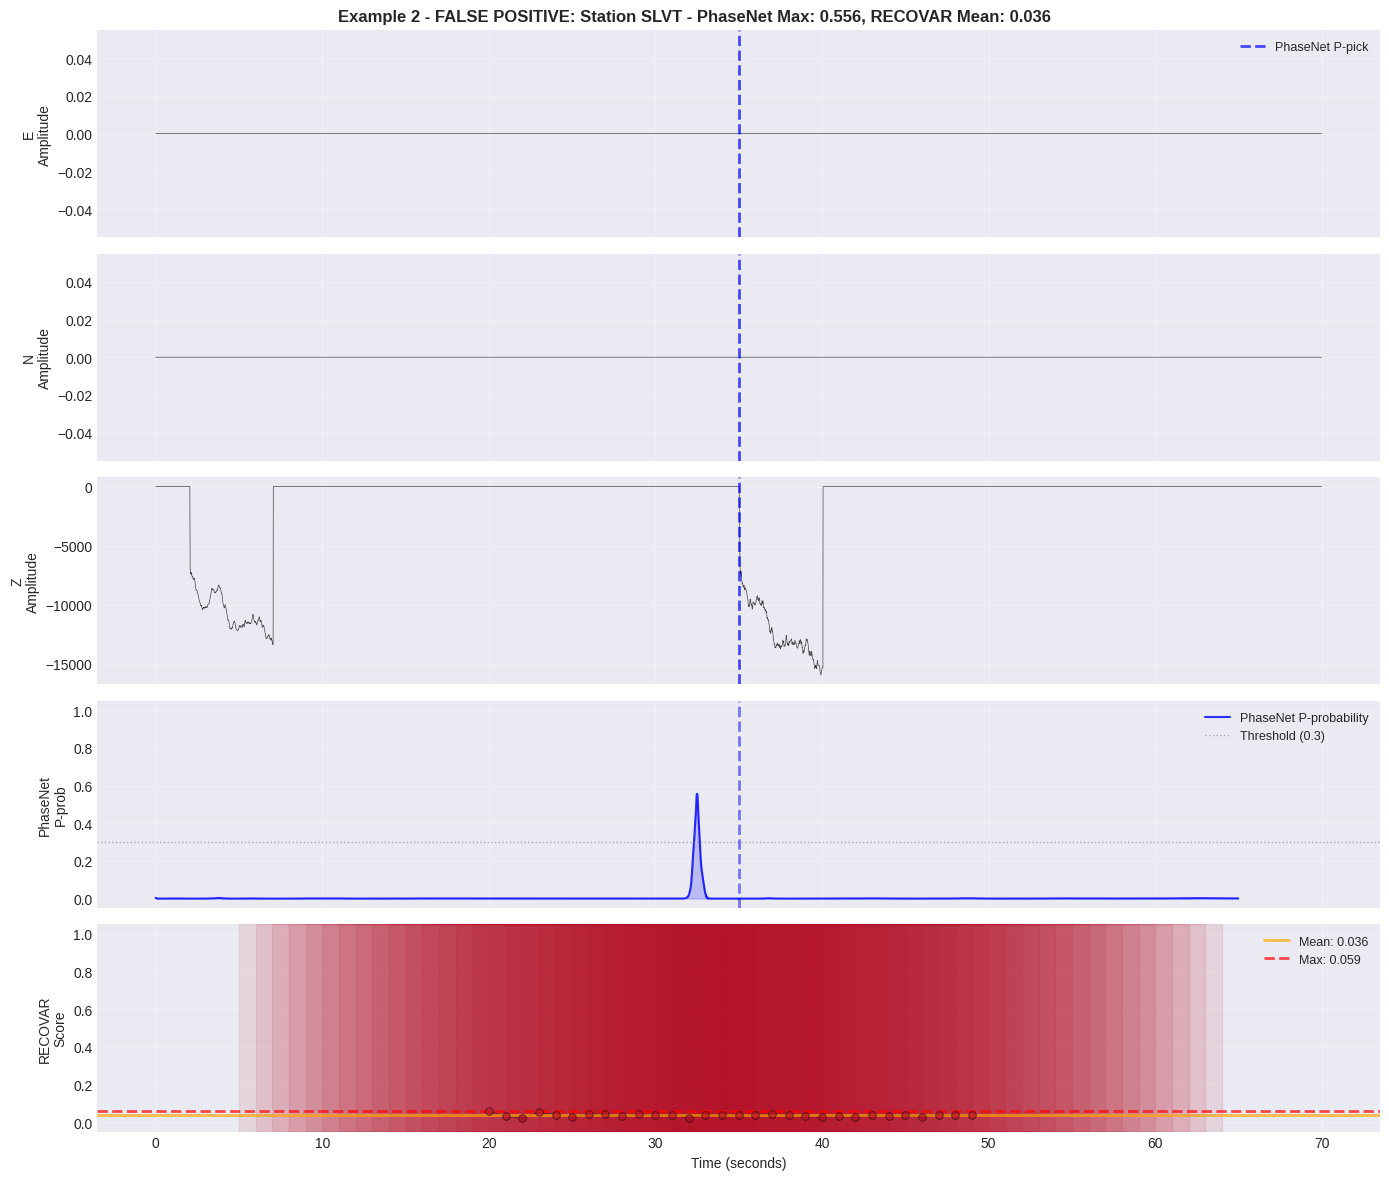

Processing False Positive example...
(30,) [0.18099701 0.11009049 0.06707996 0.05867434 0.04262775 0.03902769
 0.04959095 0.03802353 0.02947968 0.03731453 0.03096849 0.03177392
 0.02492648 0.03200239 0.02743024 0.03105193 0.02646005 0.03673601
 0.03083915 0.03223658 0.02659845 0.0340445  0.03112155 0.03531986
 0.03421366 0.0449627  0.04415447 0.04957581 0.05559707 0.07221037]
RECOVAR window coverage: 5.0s to 64.0s
Window centers plotted: 20.0s to 49.0s


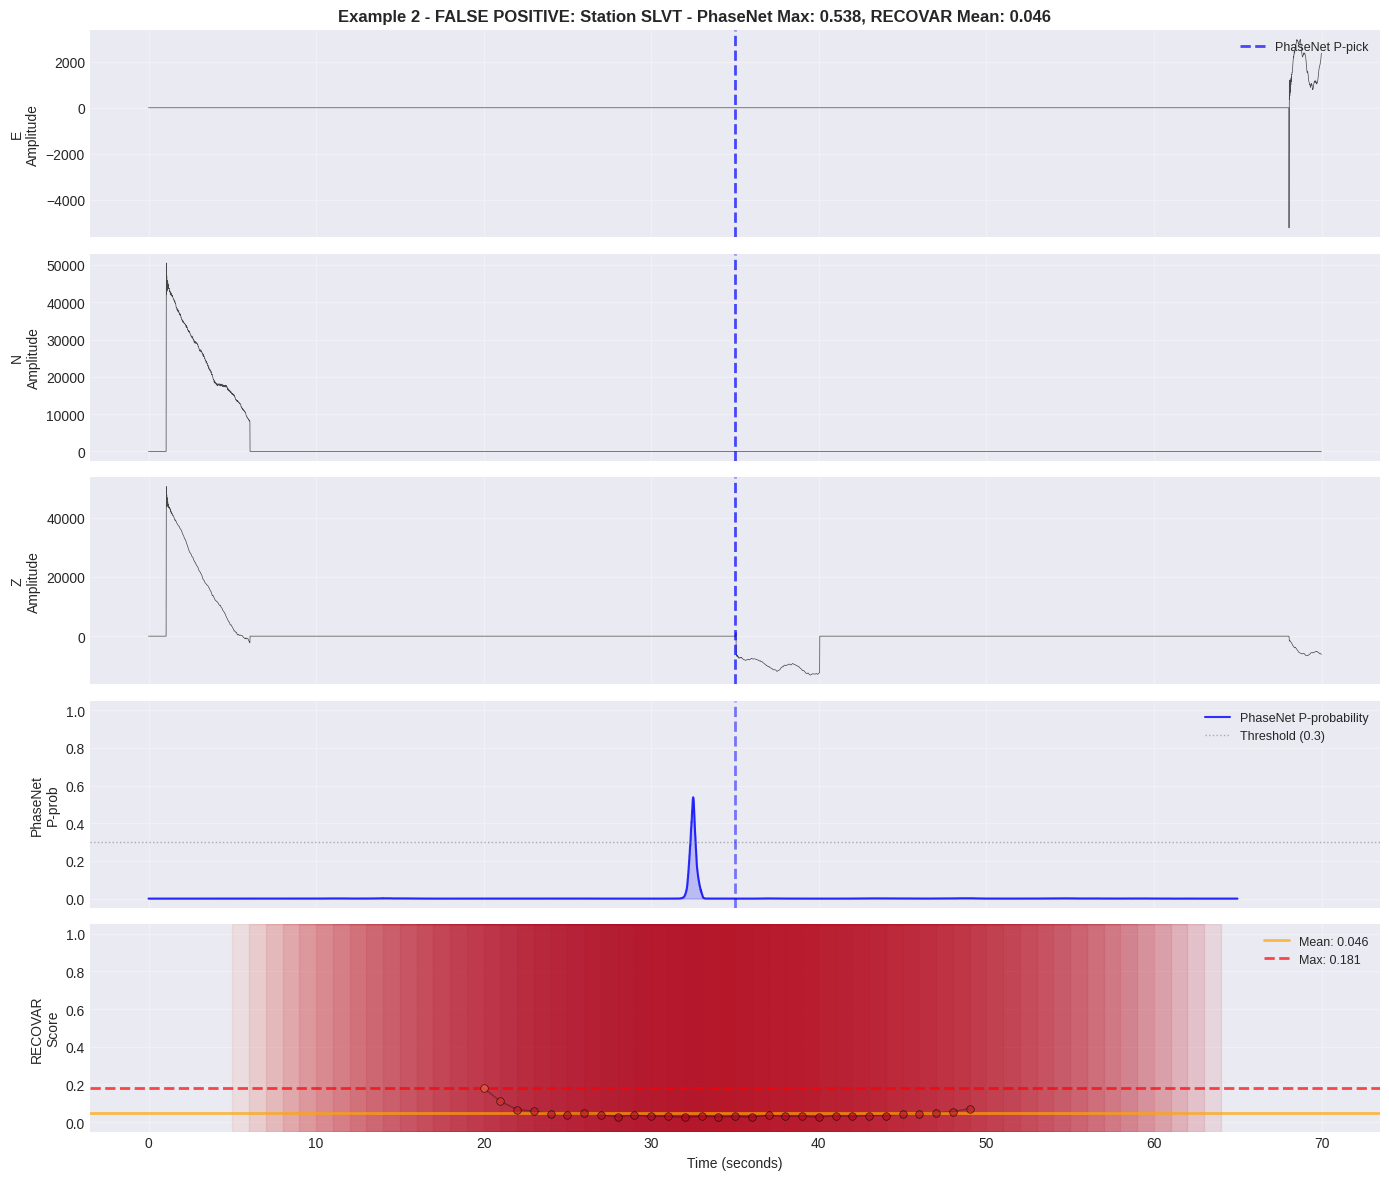

Processing False Positive example...
(30,) [0.14830935 0.16391438 0.1206575  0.09748143 0.06946844 0.05403709
 0.051085   0.03981566 0.02870381 0.03333598 0.02703393 0.02817148
 0.02016902 0.0267036  0.02344334 0.02806878 0.021694   0.03032291
 0.02518737 0.02724695 0.01996732 0.02700204 0.02463853 0.02982217
 0.02614897 0.03487682 0.03349203 0.04003644 0.04465199 0.06481791]
RECOVAR window coverage: 5.0s to 64.0s
Window centers plotted: 20.0s to 49.0s


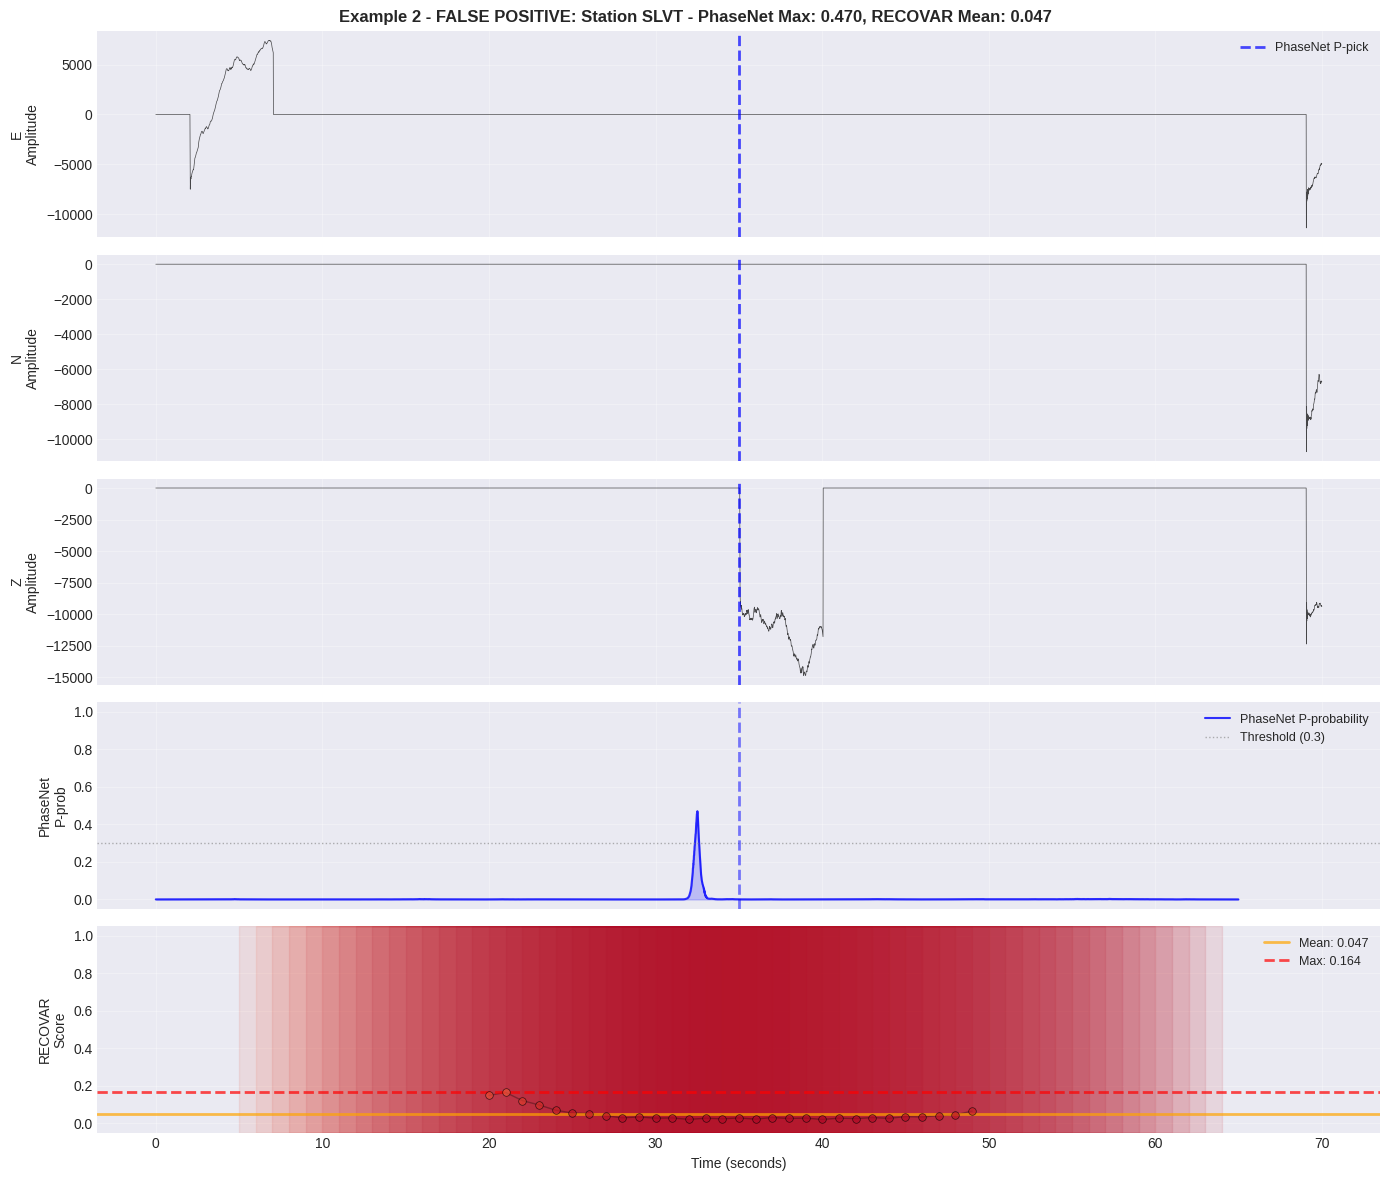

In [10]:
# Plot first False Positive
for i in range(1,4):
    if fp_examples:
        print("Processing False Positive example...")
        fp_recovar = recovar_pick_cleaner_sliding(fp_examples[i]['stream'], classifier)
        fp_phasenet = get_phasenet_probabilities(fp_examples[i]['stream'], phasenet_model, overlap=0.90)
        plot_waveform_with_scores(fp_examples[i], fp_recovar, fp_phasenet, "Example 2 - ")

## Comparison: True Positives vs False Positives

Let's process multiple examples and compare the score distributions.

In [11]:
# Process all examples
tp_results = []
fp_results = []

print("Processing True Positives...")
for example in tp_examples:
    result = recovar_pick_cleaner_sliding(example['stream'], classifier)
    tp_results.append(result)

print("Processing False Positives...")
for example in fp_examples:
    result = recovar_pick_cleaner_sliding(example['stream'], classifier)
    fp_results.append(result)

# Extract scores
tp_mean_scores = [r['mean_score'] for r in tp_results]
tp_max_scores = [r['max_score'] for r in tp_results]
fp_mean_scores = [r['mean_score'] for r in fp_results]
fp_max_scores = [r['max_score'] for r in fp_results]

print(f"\nProcessed {len(tp_results)} True Positives and {len(fp_results)} False Positives")

Processing True Positives...
Processing False Positives...

Processed 3 True Positives and 46 False Positives


In [12]:
import run_yazel_batch_sliding

Loading classifier...
Loading all waveforms...
Loaded 2214 waveforms
Processing with sliding windows in batches of 256...
Creating comparison data...

=== CATALOG STATISTICS ===

Analyzed stations: 1
Total catalog P-picks for these stations: 534
PhaseNet detected (TP): 462 (86.5%)
PhaseNet missed (FN): 72 (13.5%)

=== DETECTION STATISTICS ===

Total windows: 2214
Both (catalog + PhaseNet): 497
PhaseNet only: 1717
Catalog only: 0

=== MODEL SCORES (MEAN): BOTH (TRUE POSITIVES) ===
Count: 497
Mean: 0.236
Std: 0.120
Min: 0.019
Max: 0.688

=== MODEL SCORES (MEAN): PHASENET ONLY (FALSE POSITIVES) ===
Count: 1717
Mean: 0.066
Std: 0.071
Min: 0.002
Max: 0.612

=== MODEL SCORES (MAX): BOTH (TRUE POSITIVES) ===
Count: 497
Mean: 0.379
Std: 0.170
Min: 0.030
Max: 0.961

=== MODEL SCORES (MAX): PHASENET ONLY (FALSE POSITIVES) ===
Count: 1717
Mean: 0.115
Std: 0.115
Min: 0.005
Max: 0.946

=== FINDING BEST THRESHOLD (MEAN SCORES) ===
Best threshold: 0.131373
Best F1 score: 0.729

=== FINAL PERFORMANCE 

X AXIS THRESHOLD YAKALANAN FP VS KACIRILAN TP GRAFIGI

## Summary

- Sliding windows (both PhaseNet and RECOVAR) provide better scoring by analyzing multiple time positions
- A well-chosen threshold can filter many false positives while retaining most true positives

For batch processing and full evaluation, see `run_yazel_batch_sliding.py`